### 📊 Análise de Cirurgias CCP (Notebook Base) - 1º trimestre 2025

In [128]:
#este codigo será para filtrar e concatenar os dados, criar coluna de mortalidade e morbidade e no final criar um arquivo excel com os dados prontos e sem identificação para colocar no git hub

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import plotly.express as px
import streamlit as st
# Ajuste visual
sns.set(style='whitegrid')

In [130]:
# 📥 Carregar cada mês em um DataFrame
#df_janeiro = pd.read_excel("Janeiro 2025.xlsx")
#df_fevereiro = pd.read_excel("Fevereiro 2025.xlsx")
#df_marco = pd.read_excel("Março 2025.xlsx")
#df_abril = pd.read_excel("Abril 2025.xlsx")
df_maio_junho = pd.read_excel("df_maio_junho.xlsx")

# 🧩 Opcional: unir todos em um só DataFrame
df_total = pd.concat([df_maio_junho], ignore_index=True)



In [131]:
# 👁️ Verificar os primeiros dados
df_total.head()

,DATA,MV,CHEFE,RESIDENTE,CIRURGIA,ANEST,ANESTESISTA,INICIO,FIM,CIRCULANTE,...,DURACAO_HORAS,GRUPO_MESTRE,COMPLICACAO,QUAL,TEMPO_INTERNACAO_HORAS,TEMPO_INTERNACAO_DIAS,OBITO,REINTERNACAO_NAO_PROGRAMADA,DATA_HORA_INICIO,DATA_HORA_FIM
0,2025-05-02,219763,FRANCISCO ARAUJO DIAS (CRM - 154295),GIOVANA CRUZ CORSI (CRM - 168155),PAROTIDECTOMIA TOTAL,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-02 16:40:00,2025-05-02 19:00:00,MARIA SE,...,2.333333,Outras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-05-02,50570,VICTOR BANDINI VIEIRA (CRM - 164000),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),MANDIBULECTOMIA PARCIAL,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-02 12:30:00,2025-05-02 16:30:00,ALEX,...,4.000000,Outras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-05-02,219747,FRANCISCO ARAUJO DIAS (CRM - 154295),GIOVANA CRUZ CORSI (CRM - 168155),MAXILECTOMIA PARCIAL,GERAL,PAULO CESAR TEIXEIRA (CRM - 78084),2025-05-02 10:00:00,2025-05-02 14:40:00,NICOLE,...,4.666667,Outras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-05-02,142902,FRANCISCO ARAUJO DIAS (CRM - 154295),GIOVANA CRUZ CORSI (CRM - 168155),LARINGECTOMIA PARCIAL,GERAL,PAULO CESAR TEIXEIRA (CRM - 78084),2025-05-02 15:50:00,2025-05-02 17:20:00,BEATRIZ,...,1.500000,Laringe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-05-02,215062,VICTOR BANDINI VIEIRA (CRM - 164000),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348) ...,TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRE...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-02 07:50:00,2025-05-02 09:45:00,ALEX,...,1.916667,Tireoide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               0 non-null      float64       
 11  DURACAO_MIN                  0 non-null      

In [133]:
df_total.isnull().sum()

DATA                             0
MV                               0
CHEFE                            0
RESIDENTE                        0
CIRURGIA                         0
ANEST                            0
ANESTESISTA                      1
INICIO                           0
FIM                              0
CIRCULANTE                       0
CIRURGIA_GRUPO                 170
DURACAO_MIN                    170
DURACAO_HORAS                    0
GRUPO_MESTRE                     0
COMPLICACAO                    170
QUAL                           170
TEMPO_INTERNACAO_HORAS         170
TEMPO_INTERNACAO_DIAS          170
OBITO                          170
REINTERNACAO_NAO_PROGRAMADA    170
DATA_HORA_INICIO               170
DATA_HORA_FIM                  170
dtype: int64

In [134]:
#remover os espaços nas colunas
df_total.columns = df_total.columns.str.strip()


In [135]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               0 non-null      float64       
 11  DURACAO_MIN                  0 non-null      

In [136]:
#df_total['CLINICA'].value_counts()

In [137]:
# selecionar apenas os casos da cp:

In [138]:
#df_cp = df_total[df_total['CLINICA'] == 'CP']
df_cp = df_total.copy()

In [139]:
#antigo
#df_cp.drop(columns=['VIDEO CIRURGIA', 'VIDEOCIRURGIA', 'SUS', 'Unnamed: 14', 'CLINICA'], inplace=True)
#df_cp.drop(columns=['VLP', 'SUS', 'CLINICA'], inplace=True)

In [140]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               0 non-null      float64       
 11  DURACAO_MIN                  0 non-null      

In [141]:
df_cp['CHEFE'].value_counts()

CHEFE
FRANCISCO ARAUJO DIAS (CRM - 154295)                                                                34
MARCELO SOARES SCHALCH (CRM - 164050)                                                               34
RAFAEL DE CICCO (CRM - 112733)                                                                      31
VICTOR BANDINI VIEIRA (CRM - 164000)                                                                14
PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741)                                                        12
ERICA ERINA FUKUYAMA (CRM - 72507)                                                                  11
SANDRA CARINA LOPEZ CALCINES (CRM - 210541)                                                         11
GIOVANNA MARCELA VIEIRA DELLA NEGRA (CRM - 207914)                                                  11
JOAO                                                                                                 5
SANDRA CARINA LOPEZ CALCINES (CRM - 210541) / RAFAEL               

In [142]:
#deletar os médicos fora da clinica CP#renomear os nomes duplicados

In [143]:
# Normalização de nomes de médicos (CHEFE e RESIDENTE)from rapidfuzz import process, fuzz# Lista de médicos válidos da CCPMEDICOS_VALIDOS = [    "FRANCISCO ARAUJO DIAS (CRM - 154295)",    "MARCELO SOARES SCHALCH (CRM - 164050)",    "RAFAEL DE CICCO (CRM - 112733)",    "VICTOR BANDINI VIEIRA (CRM - 164000)",    "PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741)",    "ERICA ERINA FUKUYAMA (CRM - 72507)",    "SANDRA CARINA LOPEZ CALCINES (CRM - 210541)",    "GIOVANNA MARCELA VIEIRA DELLA NEGRA (CRM - 207914)",]def normalizar_medico(nome, lista_validos):    if pd.isna(nome):        return None        nome_upper = nome.str.upper().str.strip()        # Se já estiver na lista, retorna    for valido in lista_validos:        if nome_upper.str.contains(valido.split()[0], na=False).any():            return valido        # Fuzzy match para nomes similares    match, score = process.extractOne(nome_upper, lista_validos, scorer=fuzz.ratio)    if score > 75:        return match        return nome_upper  # mantém original se não encontrardf_cp['CHEFE'] = normalizar_medico(df_cp['CHEFE'], MEDICOS_VALIDOS)

In [144]:
df_cp = df_cp[~df_cp['CHEFE'].isin([
    "NIKKEI TAMURA (CRM - 97288)",
    "CARLOS ELIAS FRISTACHI (CRM - 44605)",
    "RODRIGO MACEDO DA SILVA (CRM - 112466)"
])]

In [145]:
cirurgias = df_cp['CIRURGIA'].dropna().unique().tolist()



In [146]:
for c in cirurgias:
    print(c)


PAROTIDECTOMIA TOTAL
MANDIBULECTOMIA PARCIAL
MAXILECTOMIA PARCIAL
LARINGECTOMIA PARCIAL
TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL
ABLACAO DE NODULOS POR MICROONDAS
DESBRIDAMENTO DE LABIO INFERIOR + KARAPANDIZIC A DIR. + AVANCO LOCAL PARA RECONTRUCAO
TIREOIDECTOMIA PARCIAL ESQ. + ISTMO
ESVAZIAMENTO CERVICAL RADICAL MODIFICADO A DIR. + DRENAGEM COM PORTOVAC
LINFADENECTOMIA RADICAL
EXCISAO E SUTURA COM PLASTICA EM Z
EXCISAO E SUTURA COM PLASTICA
BUCOFARINGECTOMIA ESQ. COM MANDIBULOTOMIA DE ACESSO + ESVAZIAMENTO CERVICAL ESQ. PARCIAL RADICAL MODIFICADO + FECHAMENTO COM RETALHO DE LINGUA + TQT + FIXACAO DE MANDIBULA COM MINIPLACA
LARINGECTOMIA PARCIAL ESQ.
EXTIRPACAO E SUSPRESSAO DE LESAO DE PELE
PGM ANTERIOR + GLOSSECTOMIA TOTAL + LARINGO SUPRAGLOTICA
RESSECCAO DE LESAO EM PALATO DURO A DIR.
TIREOIDECTOMIA TOTAL + EC NIVEL VI DIREITO
EC NIVEIS II E IV DEVIDO METASTASE DE CA PAPILIFERO DE TIREOIDE
TRAQUEORRAFIA
RECONSTRUCAO PARA FONACAO
TRAQUEOSTOMIA
ABLACAO DE NODULOS POR RADIOFR

In [147]:
#limpar os textos removendo espaços extras, apdronizando maisculas e minusculas:
df_cp['CIRURGIA'] = df_cp['CIRURGIA'].str.strip().str.upper()


In [148]:
# Agrupar as cirurgias que são iguais mas com nome diferente

In [149]:
agrupamentos = {

    'TIREOIDECTOMIA TOTAL': [
            'TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL', 
            'TIREOIDECTOMIA TOTAL (TOTALIZAÇÃO) + LINFADENECTOMIA RECORRENCIAL DIR.',
            'TIREOIDECTOMIA TOTAL',
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO NIVEL VI DIR.',
            'TIREOIDECTOMIA TOTAL + EC NIVEL VI ESQ.',
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO RECORRENCIAL DIR. + DRENAGEM COM PORTOVAC',
            'TIREIDECTOMIA TOTAL+ LINFADENECTOMIA RECORRENCIAL',
            'TIRERECTOMIA TOTAL EM ONCOLOGIA +LINFANDENECTOMIA CERVICAL RECORRENCIAL'
            'TIREOIDECTOMIA TOTAL + EC NIVEL VI DIREITO',
            'TIRERECTOMIA TOTAL EM ONCOLOGIA +LINFANDENECTOMIA CERVICAL RECORRENCIAL',
            'TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL (AMOSTRAGEM) + DRENAGEM PORTOVAC BOCIO MULTINODULAR, COM NODULO DE APROXIMANDAMENTE 3CM A DIR. SEM ADERENCIAS',
            'TIREOIDECTOMIA TOTAL + EC NIVEL VI'


           
    ],
    
    'TIREOIDECTOMIA PARCIAL': [
            'TIREOIDECTOMIA PARCIAL DIR. + ISTMO',
            'TIREOIDECTOMIA PARCIAL',
            'TIREOIDECTOMIA PARCIAL DIR. + LINFADENECTOMIA NIVEL VI',
            'TIREOIDECTOMIA PARCIAL ESQ. + ISTMO', 'TIREOIDECTOMIA PARCAIL ESQ.',
            'TIREOIDECTOMIA PARCIAL ESQ. + LINFADENECTOMIA',
            'TIREOIDECTOMIA PARCIAL - VLP',
            'TIREOIDECTOMIA PARCIAL ESQ. + LINFADENECTOMIA RECORRENCIAL',
            'TIREOIDECTOMIA PARCIAL DIR. + ISTMO + LINFADENECTOMIA RECORRENCIAL'
    ],
    
    'ABLAÇÃO DE NODULO TIREOIDIANO': [
            'ABLAÇÃO DE NODULO TIREOIDIANO POR RADIOFREQUENCIA',
            'ABLAÇÃO DE NODULO POR RADIO FREQUENCIA TIREOIDECTOMIA PARCIAL',
            'TIREOIDECTOMIA PACIAL+ABLA DE NODULO POR MICROONDAS',
            'TIREOIDECTOMIA PARCIAL DIREITA +ABLAÇÃO DENODULO TIREOIDIANO POR RADIOFREQUENCIA',
            'TIREOIDECTOMIA PARCIAL ESQUERDA COM ABLAÇÃO DE NODULO POR MICROONDAS',
            'ABLACAO DE NODULO EM LOBO ESQ. (MICROWAVE)',
            'TIREOIDECTOMIA PARCIAL - RADIOFREQUÊNCIA'
            'ABLACAO DE NODULO POR RADIOFREQUENCIA'
            'ABLACAO DE NODULO POR RADIOFREQUENCIA',
            'TIREOIDECTOMIA PARCIAL - RADIOFREQUÊNCIA',
            'ABLACAO DE NODULOS POR MICROONDAS',
            'ABLACAO DE NODULOS POR RADIOFREQUENCIA',
            'ABLACAO DE NODULO POR MICROONDAS',
            'TIREOIDECTOMIA PARCIAL (RF)',
            'AMBLACAO DE NODULO POR MICROWAVE',
    ],

    'TIREOIDECTOMIA TOTAL + EC LATERAL': [
         'TIREOIDECTOMIA TOTAL + EC NIVEIS II A IV + VI + TQT + DRENAGEM COM PORTOVAC',
         'TIREOIDECTIA TOTAL EM ONC+ LINFADENECTOMIA RADICAL MODIFICA+LINFADENECTOMIA CERVICAL RECORRENCIAL NÍVEIS I,II, III, E IV ESQUERDA',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II, III, IV, V E VI A ESQ.',
         'TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA BILATERAL + LINFADENECTOMIA RECORRENCIAL BILATERAL',
         'TIREOIDECTOMIA TOTAL + EC NIVEIS II, III, IV E VI DIR.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL II-IV DIR.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL II - IV BILATERAL + DREANGEM DE PORTOVAC',
         'TIREOIDECTOMIA TOTAL + EC NIVEL VI DIREITO',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II-VI ESQ.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II-VI ESQ.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II, III, IV, V E VI DIREITO',
         'TIREOIDECTOMIA TOTAL + EC II-IV BILATERAL + NIVEL VI BILATERAL + RESSECCAO DE MASSA LINFONODAL',
         'TIREOIDECTOMIA TOTAL + EC II - IV ESQ.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II, III, IV, V E VI A ESQ. + TQT + SNE',
         'TIREOIDECTOMIA PARCIAL ESQ. + ESVAZIAMENTO CERVICAL NIVEIS II A VI A ESQ. NIVEL VI A DIR',


    ],

    'GLOSSECTOMIA PARCIAL': [
        'GLOSSECTOMIA PARCIAL ANTERIOR',
        'GLOSSECTOMIA PARCIAL ESQ.',
        'GLOSSECTOMIA PARCIAL ESQ. + ESVAZIAMENTO CERVICAL SUPRA-OMOHIOIDEO ESQ. + RECONSTRUCAO COM RETALHO',
        'GLOSSECTOMIA SUBTOTAL + ECI A IV A DIREITA + RETALHOINFRAHIODEO',
        'GLOSSECTOMIA PARCIAL',
        'GLOSSECTOMIA PARCIAL A DIR. + EC I A IV A ESQ. + DRENAGEM DE PORTOVAC',
        'GLOSSECTOMIA SUBTOTAL + I A IV DIR. + EC I - III ESQ. + RETALHO DE PEITORAL + TQT + DRENAGEM + SNE',




    ],

      'GLOSSECTOMIA TOTAL': [
        'GLOSSECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA ESQ. + RETALHO MIOCUTANEO',
        'GLOSSECTOMIA TOTAL'

    ],

    'PGM': [
        'PELGLOSSOMANDIBULECTOMIA+  LINFADENECTOMIA CERVICAL SUPRAO+TRAQUEOSTOMIA',
        'PELGLOSSOMANDIBULECTOMIA+ RECONSTRUÇÃO COM RETALHO MIO+TRAQUEOSTOMIA(MANDIBULECTOMIA SEGMENTAR E RAMO DE MANDIBULA A ESQUERDA+TORUS MAXILAR A ESQUERDA+RESSECÇÃO DE PAREDE LATERAL ESQ DE OROFARINGE+ESVAZIAMENTOCERVICAL I,II III IV ESQ +RETALHO',
        'PELVIGLOSSOMANDIBULECTOMIA'
        'PGM + RECONSTRUCAO C/ RETALHO MIOCUTANEO',
        'PGM + RECONSTRUCAO C/ RETALHO MIOCUTANEO',
        'PELVIGLOSSOMANDIBULECTOMIA',
        "BUCOFARINGECTOMIA ESQ. COM MANDIBULOTOMIA DE ACESSO + ESVAZIAMENTO CERVICAL ESQ. PARCIAL RADICAL MODIFICADO + FECHAMENTO COM RETALHO DE LINGUA + TQT + FIXACAO DE MANDIBULA COM MINIPLACA",
        'PGM ANTERIOR + GLOSSECTOMIA TOTAL + LARINGO SUPRAGLOTICA',
        'PGM + ECSOH BILATERAL + RECONTRUCAO COM RETALHO PEITORAL + TQT + SNE + DRENO PROTOVAC',
        'PELVIGLOSSOMANDIBULECTOMIA ESQ.',
        'PELVIGLOSSOMANDIBULECTOMIA COM GLOSSECTOMIA PARCIAL + MANDIBULECTOMIA SEGMNETAR + ECSOH A DIR. + RECONTRUCAO COM RETALHO PEITORAL + TQT + DRENAGEM COM PORTOVAC',
        'PELVEGLOSSOMANDIBULECTOMIA ANTERIOR + MANDIBULECTOMIA MARGINAL + RECONST. COM RET. PEITORAL + TQT + DRENAGEM COM PORTOVAC',

    ],

    'MAXILECTOMIA': [
        'MAXILECTOMIA PARCIAL',
        'RESSECCAO DE LESAO EM PALATO DURO A DIR.',
        'MAXILECTOMIA PARCIAL'
    ],
  
  
    'TRAQUEOSTOMIA': [
        'TRAQUEOSTOMIA',
        'TRAQUEOSTOMIA DE URGENCIA + LARINGECTOMIA PARCIAL',
        'LARINGECTOMIA PARCIAL + TRAQUEOSTOMIA'
    ],

    'PROVOX': [
        'PASSAGEM DE PROTESE PROVOX',
        'TROCA DE PROVOX',
        'RECONSTRUCAO PARA FONACAO',
        'RECONTRUCAO PARA FONACAO',
        'RECONSTRUÇÃO PARA FONAÇÃO'
    
        
    ],

    'PAROTIDECTOMIA': [
       'PAROTIDECTOMIA SUPERFICIAL DIR. COM PRESERVACAO DE NERVO FACIAL (UTILIZADA MONITORIZACAO INTERMITENTE DO NERVO FACIAL)',
       'PAROTIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA UNILATERAL',
       'PAROTIDECTOMIA', 'PAROTIDECTOMIA TOTAL DIR.',
       'PAROTIDECTOMIA DIREITA TOTAL + RECONSTRUCAO COM RETALHO BILOBADO + RESSECCAO DE LESAO SUPRALABIAL A DIREITA',
       'PAROTIDECTOMIA TOTAL + RECONTRUCAO COM RETALHO BILOBADO',
       'PAROTIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA + RECONSTRUCAO PARA NERVO FACIAL',
       'PAROTIDECTOMIA TOTAL AMPLIADA A ESQ. + EC + RECONTRUCAO COM RETALHO SUPRACLAVICULAR + DRENAGEM COM PORTOVAC',
       'PAROTIDECTOMIA SUPERFICIAL DIR.',
       'PAROTIDECTOMIA TOTAL',
       'PAROTIDECTOMIA SUPERFICAL ESQ.',
       'PAROTIDECTOMIA TOTAL + RECONSTRUCAO COM RETALHO',
       'PAROTIDECTOMIA SUPERFICAL DIR.',


    ],

    'LARINGECTOMIA TOTAL': [
       'LARINGECTOMIA TOTAL + EC II-IV BILATERAL + TIREPOIDECYOMIA TOTAL + FECHAMENTO + FECHAMENTO PRIMARIO DE FARINGE + PASSAGEM DE PROVOX + DRENAGEM CERVICAL COM PORTOVAC',
       'LARINGECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICCADA BILATERAL + PROTESE PARA FONACAO',
       'LARINGECTOMIA TOTAL',
       'LARINGECTOMIA TOTAL DE RESGATE + FECHAMENTO PRIMARIO DE FARINGE + RETALHO MIOCUTANEO DE PEITORAL DIREITO + RECONSTRUCAO PARA FONACAO',
       'LARINGECTOMIA TOTAL + EC UU A V BILATERAL + TQT + SNE + DRENAGEM',


     ],



     'LARINGECTOMIA PARCIAL': [
       'LARINGECTOMIA PARCIAL', 'LARINGECTOMIA PARCIAL + TQT',
       'LARINGECTOMIA PARCIAL FRONTO-LATERAL DIR. + RETALHO MUSCULAR',
       'LARINGECTOMIA PARCIAL + TRAQUEOSTOMIA',
       'LARINGECTOMIA SUPRA CRICODEA + CHEP + EC II A IV BILATERAL + TQT + SNE + DREANGEM',
       'LARINGECTOMIA SUPRA CRICODEA + CHEP + TQT + SNE + DREANGEM',
       'LARINGECTOMIA SUPRA CRIXOIDEA + CHEP + TQT + PASSAGEM DE SNE',


     ],
       
    'RESSECCAO DE TUMOR DE LABIO': [
       'RESSECCAO DE LESAO DE LABIO INFERIOR',
       'RESSECCAO DE LESAO EM LABIO INFERIOR + RECONSTRUCAO COM RETALHO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR (CBC) + RECONSTRUCAO COM RETALHO FASCIOCUTANEO',
       'RESSECÇÃO DE LESÃO DE LABIO INFERIOR + RECONSTRUÇÃO C/ RETALHO',
       'RESSECCAO EM CUNHA DE LABIO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR + RECONSTRUCAO COM RETALHO BILOBADO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR'
     ],

    'FARINGECTOMIA PARCIAL': [
       'FARINGECTOMIA PARCIAL ESQ.', 'FARINGECTOMIA TOTAL',
       'FARINGECTOMIA + EC II A V A DIREITA + TQT + PASSAGEM DE SNE + DRENAGEM COM PORTOVAC',
       'FARINGECTOMIA PARCIAL',
       'BUCOFARINGECTOMIA ESQ. + LINFADENECTOMIA RADICAL MODIFICADA BILATERAL + RETALHO MIOFASCIOCUTANEO + TRAQUEOSTOMIA',
       'FARINGECTOMIA PARCIAL (AMIGDALECTOMIA ESQ.) + EC NIVEL II - IV ESQ. + SNE + DRENAGEM'
       'FARINGOLARINGECTOMIA PARCIAL',
       'FARINGECTOMIA PARCIAL (AMIGDALECTOMIA ESQ.) + EC NIVEL II - IV ESQ. + SNE + DRENAGEM',
       'FARINGOLARINGECTOMIA PARCIAL',
       'BUCOFARINGECTOMIA AMPLIADA PARA BASE DE LINGUA COM MANDIBULECTOMIA DE ACESSO+ EC RADICAL MODIFICADO + RECONTRUCAO COM RETALHO'
     ],

    'SEQUESTRECTOMIA': [
       'TRAQUEOSTOMIA + MANDIBULECTOMIA PARCIAL ESQ.',
       'MANDIBULESTOMIA PARCIAL ESQ.',
       'MANDIBULECTOMIA PARCIAL',
       'RESSECCAO DE OSTEORADIONECROSE DE CLAVICULA ESQUERDA',
        'MANDICULECTOMIA PARCIAL'
     ],

    'RESSECÇÃO DE SUBMANDIBULAR': [
      'RESSECCAO DE GLANDULA SUBMANDIBULAR'
      
     ],

    'RESSECÇÃO DE TUMOR DE PELE': [
       'EXCISÃO E SUTURA DE LESÃO NA PELE',
       'RESSECCAO DE LESOES DE PELE (TORAX)',
       'BIOPSIA DE PELE E PARTES MOLES',
       'RESSECÇAO DE LESÃO DE PELE EM COURO CABELUDO+ENXERTO INFRACLAVICULAR DIREITA',
       'EXCISÃO E SUTURA DE LESÃO NA PELE RESSECÇÃO DE LESÃO EM TEMPORA ESQUEDA+TARSORRAFIA+ENXERTO+CURATIVO BROWN',
       'RESECCAO DE LESAO DE PELE - TEMPORA ESQ.',
       'EXCISAO E SUTURA DE LESAO NA PELE',
       'EXTIRPACAO E SUSPRESSAO DE LESAO DE PELE',
       'AMPLIACAO DE MARGEM DE CBC EM REGIAO PARANSAL A DIR.',
       'BIOPSIA DE LESAO DE PARTES MOLES',
       'BIOPSIA DE PELE E PARTES MOLES',
       'BIÓPSIA DE LESÃO DE PARTES MOLES(BIOPSIA DE ASA NASAL',
       'AMPLIACAO DE MARGEM DE CBC EM REGIAO PARANSAL A DIR.',
       'AMPLIACAO DE MARGENS EM REGIAO RETROAURICULAR',
       'EXCISAO E SUTURA COM PLASTICA',
       'RESSECCAO DE LESAO PRE AURICULAR ESQ. + PAROTIEDCTOMIA SUPERFICAL COM PRESERVACAO DE NERVO FACIL + RETALHO DE AVANCO',
       'RESSECCAO DE LESAO CROSTOSA NASAL DIR.',
       'AMPLIACAO DE MARGENS EM REGIAO RETROAURICULAR',
       'BIÓPSIA DE LESÃO DE PARTES MOLES',
       'RESSECÇÃO DE LESÃO CERVICAL ANTERIOR',
       'RESSECCAO DE LESAO EM PAVILHAO AURICULAR/CONDUTO AUDITIVO + PAROTIDECTOMIA + RETALHO LOCAL',
       'EXTIRPACAO MULTIPLA DE LESAO DA PELE'
       

      
     ],

    'ESVAZIAMENTO CERVICAL': [
       'ESVAZIAMENTO CERVICAL ESQ.',
       'ESVAZIAMENTO CERVICAL A ESQ. + DRENAGEM COM PORTVAC',
       'ESVAZIAMENTO CERVICAL RECORRENCIAL BILATERAL',
       'ESVAZIAMENTO CERVICAL UNILATERAL',
       'ESVAZIAMENTO CERVICAL II-IV BILATERAL + DRANAGEM COM PORTOVAC',
       'ESVAZIAMENTO RADICAL MODIFICADO UNILATERAL + ESVAZIAMENTO CERVICAL RECORRENCIAL UNILATERAL',
       'ESVAZIAMENTO CERVICAL DIR. II E IV + VI',
       'ESVAZIAMENTO CERVICAL DIR. + DRENAGEM DE PORTOVAC',
       'LINFADENECTOMIA RADICAL MODIFICA',
       'ESVAZIAMENTO CERVICAL RADICAL MODIFICADO A DIR. + DRENAGEM COM PORTOVAC',
       'EC NIVEIS II E IV DEVIDO METASTASE DE CA PAPILIFERO DE TIREOIDE',
       'ESVAZIAMENTO CERVICAL NIVEL VI BILATERAL',
       'LARINGECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA BILATERAL',
       'ESVAZIAMENTO CERVICAL RADICAL DIR.',
       'LINFADENECTOMIA CERVICAL',


     ]

}


In [150]:
#função para pesquisar cirurgias

#df_cp[df_cp['CIRURGIA'].str.contains('CBC', case=False, na=False)]['CIRURGIA'].unique()


In [151]:
#CRIAR UMA COLUNA COM OS AGRUPAMENTOS (com fuzzy matching)from rapidfuzz import process, fuzzdef mapear_grupo_fuzzy(cirurgia):    if pd.isna(cirurgia):        return 'OUTRAS'        for grupo, lista in agrupamentos.items():        match, score = process.extractOne(cirurgia, lista, scorer=fuzz.ratio)        if score > 80:            return grupo    return 'OUTRAS'df_cp['CIRURGIA_GRUPO'] = df_cp['CIRURGIA'].apply(mapear_grupo_fuzzy)

In [152]:
#df_cp['CIRURGIA_GRUPO'].value_counts()

In [153]:
#df_outros = df_cp[df_cp['CIRURGIA_GRUPO'] == 'OUTRAS']


In [154]:
#df_outros['CIRURGIA'].unique()


In [155]:
#df_outros['CIRURGIA'].value_counts()


In [156]:
df_cp['CIRURGIA_GRUPO'].value_counts()

CIRURGIA_GRUPO
OUTRAS                               36
TIREOIDECTOMIA TOTAL                 33
TRAQUEOSTOMIA                        15
RESSECÇÃO DE TUMOR DE PELE           13
LARINGECTOMIA PARCIAL                11
PAROTIDECTOMIA                        8
ABLAÇÃO DE NODULO TIREOIDIANO         7
TIREOIDECTOMIA TOTAL + EC LATERAL     7
ESVAZIAMENTO CERVICAL                 6
PGM                                   6
PROVOX                                6
TIREOIDECTOMIA PARCIAL                5
LARINGECTOMIA TOTAL                   4
GLOSSECTOMIA PARCIAL                  4
SEQUESTRECTOMIA                       3
MAXILECTOMIA                          3
FARINGECTOMIA PARCIAL                 2
GLOSSECTOMIA TOTAL                    1
Name: count, dtype: int64

#### Corrigir as horas para formato brasileiro e gerar coluna duração em minutos e horas

In [157]:
# Função para corrigir turno (03:00 → 15:00, se necessário)
def corrigir_turno(hora):
    if pd.isna(hora):
        return None

    hora_str = str(hora).strip()

    # Se já for datetime ou time, transforma em string no formato HH:MM:SS
    if isinstance(hora, pd._libs.tslibs.timestamps.Timestamp):
        hora_str = hora.strftime('%H:%M:%S')

    try:
        h = int(hora_str[:2])
        if h < 7:
            nova_hora = str(h + 12).zfill(2) + hora_str[2:]
        else:
            nova_hora = hora_str
        return pd.to_datetime(nova_hora, format='%H:%M:%S', errors='coerce').time()
    except:
        return None  # Se falhar (ex: string inválida), retorna None

# Aplicar a função nas colunas de horário
df_cp['INICIO'] = df_cp['INICIO'].apply(corrigir_turno)
df_cp['FIM'] = df_cp['FIM'].apply(corrigir_turno)

# Unir com a coluna de DATA para gerar datetime completo
df_cp['INICIO'] = pd.to_datetime(df_cp['DATA'].astype(str) + ' ' + df_cp['INICIO'].astype(str), errors='coerce')
df_cp['FIM'] = pd.to_datetime(df_cp['DATA'].astype(str) + ' ' + df_cp['FIM'].astype(str), errors='coerce')

# Calcular duração em minutos
df_cp['DURACAO_MIN'] = (df_cp['FIM'] - df_cp['INICIO']).dt.total_seconds() / 60

In [158]:
df_cp['DURACAO_HORAS'] = df_cp['DURACAO_MIN'] / 60

In [159]:
df_cp.shape

(170, 22)

# 🤝 - Concluido a limpeza dos dados

In [160]:
df_cp_EAD = df_cp.copy()

In [161]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               170 non-null    object        
 11  DURACAO_MIN                  170 non-null    

In [162]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               170 non-null    object        
 11  DURACAO_MIN                  170 non-null    

## 1️⃣ Contagem de cirurgias

In [163]:
# Contagem dos grupos
grupo_counts = df_cp_EAD['CIRURGIA_GRUPO'].value_counts().reset_index()
grupo_counts.columns = ['Grupo de Cirurgia', 'Quantidade']

# Gráfico com barras horizontais e cores distintas
fig = px.bar(
    grupo_counts,
    x='Quantidade',
    y='Grupo de Cirurgia',
    orientation='h',
    color='Grupo de Cirurgia',  # Garante cores distintas
    title='Frequência por Grupo de Cirurgia',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Safe  # Ou outra paleta como 'Plotly', 'Pastel', etc.
)

fig.update_layout(
    xaxis_title='Número de Casos',
    yaxis_title='Grupo de Cirurgia',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=True
)

fig.show()



In [164]:
df_cp_EAD['CIRURGIA_GRUPO'].value_counts()

CIRURGIA_GRUPO
OUTRAS                               36
TIREOIDECTOMIA TOTAL                 33
TRAQUEOSTOMIA                        15
RESSECÇÃO DE TUMOR DE PELE           13
LARINGECTOMIA PARCIAL                11
PAROTIDECTOMIA                        8
ABLAÇÃO DE NODULO TIREOIDIANO         7
TIREOIDECTOMIA TOTAL + EC LATERAL     7
ESVAZIAMENTO CERVICAL                 6
PGM                                   6
PROVOX                                6
TIREOIDECTOMIA PARCIAL                5
LARINGECTOMIA TOTAL                   4
GLOSSECTOMIA PARCIAL                  4
SEQUESTRECTOMIA                       3
MAXILECTOMIA                          3
FARINGECTOMIA PARCIAL                 2
GLOSSECTOMIA TOTAL                    1
Name: count, dtype: int64

#### Agrupar em doenças:

In [165]:
mapa_grupo_mestre = {
    # TIREOIDE
    'TIREOIDECTOMIA TOTAL': 'Tireoide',
    'TIREOIDECTOMIA PARCIAL': 'Tireoide',
    'TIREOIDECTOMIA TOTAL + EC LATERAL': 'Tireoide',
    'ABLAÇÃO DE NODULO TIREOIDIANO': 'Tireoide',

    # GLÂNDULA SALIVAR
    'PAROTIDECTOMIA': 'Glândula salivar',
    'RESSECÇÃO DE SUBMANDIBULAR': 'Glândula salivar',

    # FARINGE
    'FARINGECTOMIA PARCIAL': 'Faringe',

    # PELE
    'RESSECÇÃO DE TUMOR DE PELE': 'Pele',

    # LARINGE
    'LARINGECTOMIA PARCIAL': 'Laringe',
    'LARINGECTOMIA TOTAL': 'Laringe',
    'TRAQUEOSTOMIA': 'Laringe',
    'PROVOX': 'Laringe',

    # BOCA
    'GLOSSECTOMIA PARCIAL': 'Boca',
    'GLOSSECTOMIA TOTAL': 'Boca',
    'RESSECCAO DE TUMOR DE LABIO': 'Boca',
    'PGM': 'Boca',

    # OUTRAS
    'SEQUESTRECTOMIA': 'Outras',
    'ESVAZIAMENTO CERVICAL': 'Outras',
    'OUTRAS': 'Outras'
}



In [166]:
df_cp_EAD['GRUPO_MESTRE'] = df_cp_EAD['CIRURGIA_GRUPO'].map(mapa_grupo_mestre).fillna('Outras')


In [167]:
df_cp_EAD['GRUPO_MESTRE'].value_counts()

GRUPO_MESTRE
Tireoide            52
Outras              48
Laringe             36
Pele                13
Boca                11
Glândula salivar     8
Faringe              2
Name: count, dtype: int64

In [168]:
# Contagem por grupo mestre
grupo_mestre_counts = df_cp_EAD['GRUPO_MESTRE'].value_counts().reset_index()
grupo_mestre_counts.columns = ['Grupo Mestre', 'Quantidade']

# Gráfico
fig = px.bar(
    grupo_mestre_counts,
    x='Quantidade',
    y='Grupo Mestre',
    orientation='h',
    color='Grupo Mestre',
    title='Distribuição por Patologia',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Número de Cirurgias',
    yaxis_title='Grupo Mestre',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig.show()


### 2️⃣ Tempo de cirurgia

In [169]:
df_cp_EAD['DURACAO_HORAS'].describe()

count    170.000000
mean       2.151667
std        1.695016
min        0.083333
25%        0.854167
50%        1.833333
75%        2.729167
max        8.416667
Name: DURACAO_HORAS, dtype: float64

<Axes: >

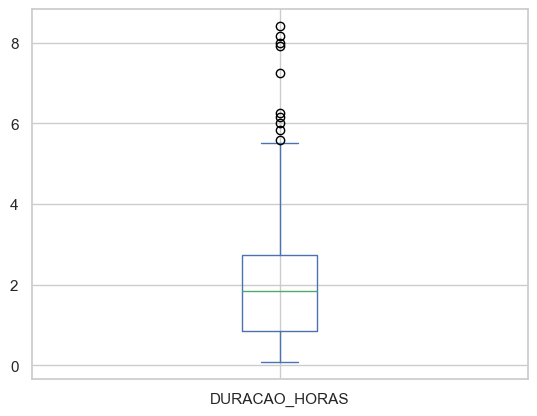

In [170]:
df_cp_EAD['DURACAO_HORAS'].plot.box()

In [171]:
cirurgias_maior_5h = df_cp_EAD[df_cp_EAD['DURACAO_HORAS'] > 5]



In [172]:
cirurgias_maior_5h


,DATA,MV,CHEFE,RESIDENTE,CIRURGIA,ANEST,ANESTESISTA,INICIO,FIM,CIRCULANTE,...,DURACAO_HORAS,GRUPO_MESTRE,COMPLICACAO,QUAL,TEMPO_INTERNACAO_HORAS,TEMPO_INTERNACAO_DIAS,OBITO,REINTERNACAO_NAO_PROGRAMADA,DATA_HORA_INICIO,DATA_HORA_FIM
15,2025-05-07,221031,FRANCISCO ARAUJO DIAS (CRM - 154295),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),BUCOFARINGECTOMIA ESQ. COM MANDIBULOTOMIA DE A...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-07 10:30:00,2025-05-07 16:00:00,ALEX,...,5.500000,Boca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2025-05-09,222340,RAFAEL DE CICCO (CRM - 112733),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),PGM ANTERIOR + GLOSSECTOMIA TOTAL + LARINGO SU...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-09 08:00:00,2025-05-09 14:00:00,ALEX,...,6.000000,Boca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,2025-05-14,220984,FRANCISCO ARAUJO DIAS (CRM - 154295),GIOVANA CRUZ CORSI (CRM - 168155),LARINGECTOMIA TOTAL,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-05-14 07:50:00,2025-05-14 13:25:00,ANTONIA,...,5.583333,Laringe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,2025-05-19,222999,MARCELO SOARES SCHALCH (CRM - 164050),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),PGM + ECSOH BILATERAL + RECONTRUCAO COM RETALH...,GERAL,ANNA KARENY DE SOUZA NAZARETH (CRM - 160550),2025-05-19 13:35:00,2025-05-19 20:50:00,MARIA SE,...,7.250000,Boca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,2025-05-26,222348,MARCELO SOARES SCHALCH (CRM - 164050),GIOVANA CRUZ CORSI (CRM - 168155),BUCOFARINGECTOMIA AMPLIADA PARA BASE DE LINGUA...,GERAL,ANNA KARENY DE SOUZA NAZARETH (CRM - 160550),2025-05-26 14:40:00,2025-05-26 22:50:00,MARIA SE,...,8.166667,Faringe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,2025-05-26,216082,MARCELO SOARES SCHALCH (CRM - 164050),GIOVANA CRUZ CORSI (CRM - 168155),TIREOIDECTOMIA TOTAL,GERAL,ANNA KARENY DE SOUZA NAZARETH (CRM - 160550),2025-05-26 08:10:00,2025-05-26 14:00:00,ALEX,...,5.833333,Tireoide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,2025-06-02,224715,MARCELO SOARES SCHALCH (CRM - 164050),GIOVANA CRUZ CORSI (CRM - 168155),PELVIGLOSSOMANDIBULECTOMIA COM GLOSSECTOMIA PA...,GERAL,ANNA KARENY DE SOUZA NAZARETH (CRM - 160550),2025-06-02 08:25:00,2025-06-02 16:50:00,ALEX,...,8.416667,Boca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,2025-06-06,225449,VICTOR BANDINI VIEIRA (CRM - 164000),GIOVANA CRUZ CORSI (CRM - 168155),TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL N...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-06-06 12:30:00,2025-06-06 18:40:00,ALEX,...,6.166667,Tireoide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,2025-06-13,225126,RAFAEL DE CICCO (CRM - 112733),GIOVANA CRUZ CORSI (CRM - 168155),LARINGECTOMIA TOTAL,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-06-13 08:15:00,2025-06-13 14:30:00,AMANDA,...,6.250000,Laringe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,2025-06-16,221070,JOAO,GIOVANA CRUZ CORSI (CRM - 168155),PELVEGLOSSOMANDIBULECTOMIA ANTERIOR + MANDIBUL...,GERAL,DEBORA VENTURA IZAR (CRM - 151521),2025-06-16 10:35:00,2025-06-16 18:30:00,AMANDA,...,7.916667,Boca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
cirurgias_maior_5h[['CHEFE', 'CIRURGIA', 'DURACAO_HORAS']]


,CHEFE,CIRURGIA,DURACAO_HORAS
15,FRANCISCO ARAUJO DIAS (CRM - 154295),BUCOFARINGECTOMIA ESQ. COM MANDIBULOTOMIA DE A...,5.500000
24,RAFAEL DE CICCO (CRM - 112733),PGM ANTERIOR + GLOSSECTOMIA TOTAL + LARINGO SU...,6.000000
40,FRANCISCO ARAUJO DIAS (CRM - 154295),LARINGECTOMIA TOTAL,5.583333
53,MARCELO SOARES SCHALCH (CRM - 164050),PGM + ECSOH BILATERAL + RECONTRUCAO COM RETALH...,7.250000
73,MARCELO SOARES SCHALCH (CRM - 164050),BUCOFARINGECTOMIA AMPLIADA PARA BASE DE LINGUA...,8.166667
74,MARCELO SOARES SCHALCH (CRM - 164050),TIREOIDECTOMIA TOTAL,5.833333
92,MARCELO SOARES SCHALCH (CRM - 164050),PELVIGLOSSOMANDIBULECTOMIA COM GLOSSECTOMIA PA...,8.416667
105,VICTOR BANDINI VIEIRA (CRM - 164000),TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL N...,6.166667
121,RAFAEL DE CICCO (CRM - 112733),LARINGECTOMIA TOTAL,6.250000
129,JOAO,PELVEGLOSSOMANDIBULECTOMIA ANTERIOR + MANDIBUL...,7.916667


### 3️⃣ Produtividade por assistente

In [174]:
df_cp_EAD['CHEFE'].value_counts()

CHEFE
FRANCISCO ARAUJO DIAS (CRM - 154295)                                                                34
MARCELO SOARES SCHALCH (CRM - 164050)                                                               34
RAFAEL DE CICCO (CRM - 112733)                                                                      31
VICTOR BANDINI VIEIRA (CRM - 164000)                                                                14
PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741)                                                        12
ERICA ERINA FUKUYAMA (CRM - 72507)                                                                  11
SANDRA CARINA LOPEZ CALCINES (CRM - 210541)                                                         11
GIOVANNA MARCELA VIEIRA DELLA NEGRA (CRM - 207914)                                                  11
JOAO                                                                                                 5
SANDRA CARINA LOPEZ CALCINES (CRM - 210541) / RAFAEL               

In [175]:

# Contagem por chefe
chefe_counts = df_cp_EAD['CHEFE'].value_counts().reset_index()
chefe_counts.columns = ['Chefe', 'Quantidade']

# Gráfico
fig = px.bar(
    chefe_counts,
    x='Quantidade',
    y='Chefe',
    orientation='h',
    color='Chefe',
    title='Número de Cirurgias por Chefe',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Número de Cirurgias',
    yaxis_title='Chefe Responsável',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig.show()


In [176]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATA                         170 non-null    datetime64[ns]
 1   MV                           170 non-null    int64         
 2   CHEFE                        170 non-null    object        
 3   RESIDENTE                    170 non-null    object        
 4   CIRURGIA                     170 non-null    object        
 5   ANEST                        170 non-null    object        
 6   ANESTESISTA                  169 non-null    object        
 7   INICIO                       170 non-null    datetime64[ns]
 8   FIM                          170 non-null    datetime64[ns]
 9   CIRCULANTE                   170 non-null    object        
 10  CIRURGIA_GRUPO               170 non-null    object        
 11  DURACAO_MIN                  170 non-null    

In [177]:
df_cp_EAD['MV'].head()

0    219763
1     50570
2    219747
3    142902
4    215062
Name: MV, dtype: int64

In [178]:
#CRIAR COLUNAS QUE FALTAM

In [179]:
df_cp_EAD2 = df_cp_EAD.copy()

In [180]:
df_cp_EAD2['COMPLICACAO'] = ""  # ou pd.NA, se preferir nulo
df_cp_EAD2['QUAL'] = ""
df_cp_EAD2['TEMPO_INTERNACAO_HORAS'] = pd.NA
df_cp_EAD2['TEMPO_INTERNACAO_DIAS'] = pd.NA
df_cp_EAD2['OBITO'] = ""
df_cp_EAD2['REINTERNACAO_NAO_PROGRAMADA'] = ""


In [181]:
#deletar o nome dos pacientes para gerar o arquivo para subir no github
#df_cp_EAD2.drop(columns=['PACIENTE'], inplace=True)

In [182]:
#Produzir planilha nova para alimentar o dashboard
df_cp_EAD2.to_excel("C:/Users/franc/Desktop/cirurgias_cp_1ºtrim.xlsx", index=False)
